Rendering Perfect Linkedin Video...
RENDER COMPLETE!


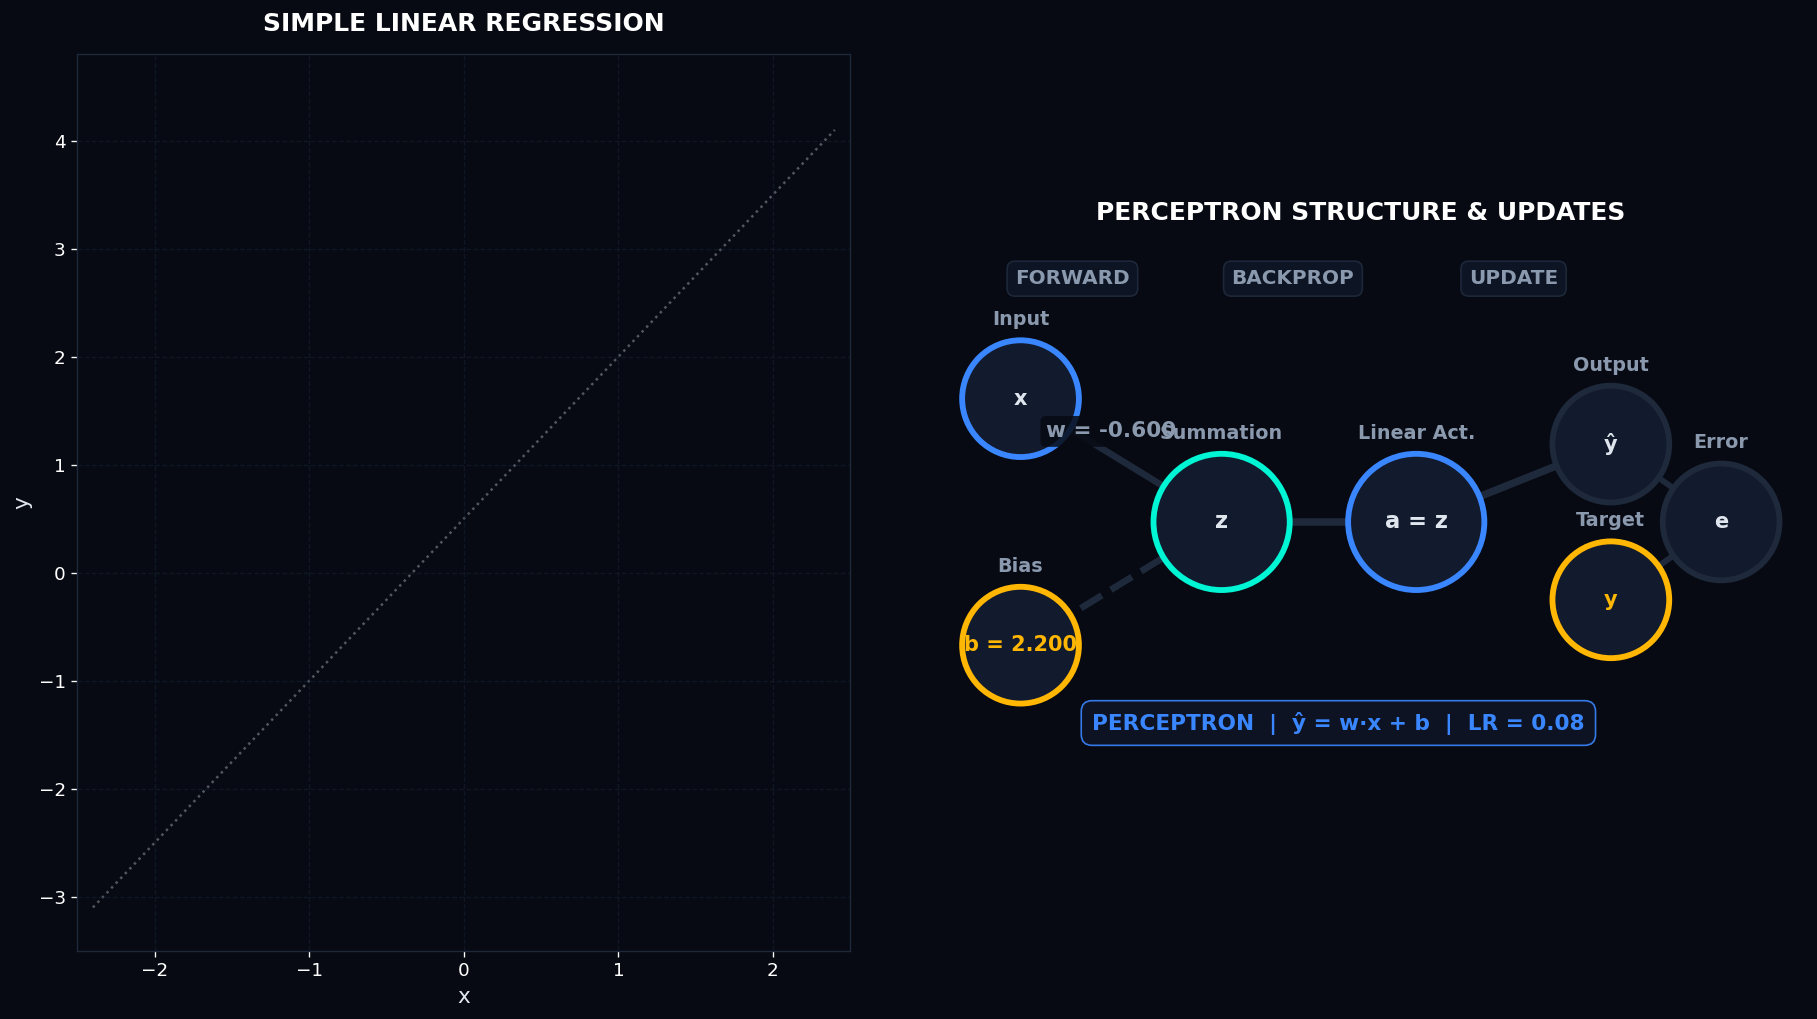

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import imageio_ffmpeg

# ---------- theme ----------
plt.style.use('dark_background')
BG    = '#070A12'
NODE  = '#121A2D'
CYAN  = '#00F5D4'
RED   = '#FF0055'
GREEN = '#3AFF8C'
AMBER = '#FFB703'
BLUE  = '#3A86FF'
TEXT  = '#E0E6ED'
GRID  = '#1C2942'
LINE  = '#1E293B'
MUTE  = '#8A99AD'

# ---------- data ----------
np.random.seed(42)
N = 35
x = np.linspace(-2.2, 2.2, N)
w_true, b_true = 1.5, 0.5
y = w_true * x + b_true + np.random.normal(0, 0.5, N)

# ---------- model ----------
w, b = -0.6, 2.2
lr = 0.08
ITERS = 30
order = np.random.permutation(N)
sched = [int(order[k]) for k in range(ITERS)]

# ---------- schedule ----------
w_hist, b_hist = [w], [b]
mse_hist = [float(np.mean((w * x + b - y) ** 2))]
for k in range(ITERS):
    i = sched[k]
    yhat = w * x[i] + b
    err = y[i] - yhat
    w += lr * err * x[i]
    b += lr * err
    w_hist.append(w)
    b_hist.append(b)
    mse_hist.append(float(np.mean((w * x + b - y) ** 2)))

# ---------- figure ----------
fig = plt.figure(figsize=(16, 9), dpi=120)
fig.patch.set_facecolor(BG)

# Padding adjustment for clean boundaries
fig.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.07)

gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.15], wspace=0.08)
axL = fig.add_subplot(gs[0])
axR = fig.add_subplot(gs[1])

# perceptron geometry - repositioned to avoid overlap
inp_pos  = (-4.6, 1.8)
bias_pos = (-4.6, -2.0)
sum_pos  = (-1.5, -0.1)
act_pos  = (1.5, -0.1)
out_pos  = (4.5, 1.1)
tgt_pos  = (4.5, -1.3)
err_pos  = (6.2, -0.1)

TOTAL = 900
ITER_START = 230
ITER_LEN = 21
FWD_END = 8
ERR_END = 14

def smooth(t):
    """smoothstep easing"""
    t = np.clip(t, 0.0, 1.0)
    return t * t * (3 - 2 * t)

def get_state(frame):
    """read state"""
    if frame < ITER_START:
        return dict(k=-1, sub=0, phase='idle', xi=None, yi=None,
                    w_disp=w_hist[0], b_disp=b_hist[0], z=0, err=0, dw=0, db=0,
                    w_new=w_hist[0], b_new=b_hist[0], mse_disp=mse_hist[0])
    k = min((frame - ITER_START) // ITER_LEN, ITERS - 1)
    sub = (frame - ITER_START) % ITER_LEN
    i = sched[k]
    xi, yi = x[i], y[i]
    w_cur, b_cur = w_hist[k], b_hist[k]
    w_new, b_new = w_hist[k + 1], b_hist[k + 1]
    z0 = w_cur * xi + b_cur
    err0 = yi - z0
    dw = lr * err0 * xi
    db = lr * err0
    if sub < FWD_END:
        phase = 'forward'
        w_disp, b_disp = w_cur, b_cur
        mse_disp = mse_hist[k]
    elif sub < ERR_END:
        phase = 'error'
        w_disp, b_disp = w_cur, b_cur
        mse_disp = mse_hist[k]
    else:
        phase = 'update'
        e = smooth((sub - ERR_END) / (ITER_LEN - ERR_END))
        w_disp = w_cur + e * (w_new - w_cur)
        b_disp = b_cur + e * (b_new - b_cur)
        mse_disp = mse_hist[k] + e * (mse_hist[k + 1] - mse_hist[k])
    if frame >= TOTAL - 40:
        phase = 'final'
        w_disp, b_disp = w_hist[-1], b_hist[-1]
        mse_disp = mse_hist[-1]
    z = w_disp * xi + b_disp
    err = yi - z
    return dict(k=k, sub=sub, phase=phase, xi=xi, yi=yi,
                w_disp=w_disp, b_disp=b_disp, z=z, err=err, dw=dw, db=db,
                w_new=w_new, b_new=b_new, mse_disp=mse_disp)

def path_point(path, t):
    """point path"""
    pts = [np.array(p) for p in path]
    segs = [np.linalg.norm(pts[i + 1] - pts[i]) for i in range(len(pts) - 1)]
    total = sum(segs)
    d = t * total
    for i, s in enumerate(segs):
        if d <= s or i == len(segs) - 1:
            f = d / s if s > 0 else 0
            return pts[i] + f * (pts[i + 1] - pts[i])
        d -= s
    return pts[-1]

def draw_left(ax, frame, st):
    """draw regression panel"""
    ax.set_facecolor(BG)
    ax.set_xlim(-2.5, 2.5)
    
    # Expanded y-limits to show top scatter points clearly
    ax.set_ylim(-3.5, 4.8)
    
    ax.grid(True, color=GRID, linestyle='--', alpha=0.4)
    ax.set_title('SIMPLE LINEAR REGRESSION', color='white', fontsize=15, fontweight='bold', pad=14)
    ax.set_xlabel('x', color=TEXT, fontsize=13)
    ax.set_ylabel('y', color=TEXT, fontsize=13)
    ax.tick_params(labelsize=11)
    for s in ax.spines.values():
        s.set_color(LINE)

    # true line
    ax.plot([-2.4, 2.4], [w_true * -2.4 + b_true, w_true * 2.4 + b_true],
            color=TEXT, lw=1.5, linestyle=':', alpha=0.35, zorder=1)

    # data points
    n_show = int(smooth(frame / 70.0) * N)
    ax.scatter(x[:n_show], y[:n_show], s=110, color=BLUE, alpha=0.9,
               edgecolor='white', linewidth=1.0, zorder=4)

    w_disp, b_disp = st['w_disp'], st['b_disp']

    # regression line
    if frame >= 70:
        lf = smooth((frame - 70) / 50.0)
        x0, x1 = -2.4, -2.4 + 4.8 * lf
        ax.plot([x0, x1], [w_disp * x0 + b_disp, w_disp * x1 + b_disp], color=CYAN, lw=4.5, zorder=3)

    # residual lines
    if frame >= 120:
        rf = smooth((frame - 120) / 80.0)
        n_res = int(rf * N)
        for i in range(n_res):
            yline = w_disp * x[i] + b_disp
            col = CYAN if y[i] >= yline else RED
            ax.plot([x[i], x[i]], [yline, y[i]], color=col, lw=2.0, alpha=0.65, linestyle='--', zorder=2)

    # sample highlight
    if st['k'] >= 0:
        i = sched[st['k']]
        yline = w_disp * x[i] + b_disp
        ax.scatter([x[i]], [y[i]], s=380, color=AMBER, alpha=0.3, zorder=5)
        ax.scatter([x[i]], [y[i]], s=140, color=AMBER, edgecolor='white', linewidth=1.8, zorder=6)
        ax.plot([x[i], x[i]], [yline, y[i]], color=AMBER, lw=3.0, linestyle='--', zorder=5)

    # mse box
    if frame >= ITER_START:
        mc = GREEN if st['mse_disp'] < 0.5 else AMBER if st['mse_disp'] < 1.5 else RED
        ax.text(0.05, 0.94, 'MSE = %.3f' % st['mse_disp'], transform=ax.transAxes, color=mc,
                fontsize=17, fontweight='bold', ha='left', va='top',
                bbox=dict(boxstyle='round,pad=0.45', facecolor=NODE, edgecolor=mc, alpha=0.95))
        ax.text(0.05, 0.83, 'Iteration %d / %d' % (st['k'] + 1, ITERS), transform=ax.transAxes,
                color=TEXT, fontsize=13, ha='left', va='top', fontweight='bold')

    # progress bar
    if frame >= ITER_START:
        prog = (st['k'] + 1) / ITERS
        ax.add_patch(plt.Rectangle((-2.4, -3.38), 4.8, 0.22, facecolor=NODE, edgecolor=LINE, lw=1.2, zorder=1))
        ax.add_patch(plt.Rectangle((-2.4, -3.38), 4.8 * prog, 0.22, facecolor=GREEN, alpha=0.85, zorder=2))
        ax.text(0.0, -3.05, 'TRAINING PROGRESS', color=MUTE, fontsize=10, ha='center', va='center', fontweight='bold', zorder=3)

    # final banner
    if frame >= TOTAL - 40:
        ax.text(0.5, 0.08, 'FINAL MODEL | CONVERGED', transform=ax.transAxes, color='white',
                fontsize=14, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=GREEN, edgecolor='white', alpha=0.95))

def data_node(ax, pos, r, edge, label, value, fs_lab=11.5, fs_val=13.0, vcol=TEXT, lcol=None):
    """draw node"""
    ax.add_patch(plt.Circle(pos, r, color=NODE, ec=edge, lw=3.5, zorder=3))
    ax.text(pos[0], pos[1] + r + 0.32, label, color=lcol or MUTE, fontsize=fs_lab,
            ha='center', va='center', fontweight='bold', zorder=4)
    ax.text(pos[0], pos[1], value, color=vcol, fontsize=fs_val,
            ha='center', va='center', fontweight='bold', zorder=4)

def draw_perceptron(ax, frame, st):
    """draw perceptron panel"""
    ax.set_facecolor(BG)
    ax.set_xlim(-6.2, 7.5)
    ax.set_ylim(-3.8, 4.2)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('PERCEPTRON STRUCTURE & UPDATES', color='white', fontsize=15, fontweight='bold', pad=14)

    phase = st['phase']
    sub = st['sub']
    w_disp, b_disp = st['w_disp'], st['b_disp']

    # status pills pushed higher (y=3.65) to fix overlap
    active_map = {'forward': 0, 'error': 1, 'update': 2, 'final': 2, 'idle': -1}
    active = active_map[phase]
    for idx, (name, col) in enumerate([('FORWARD', CYAN), ('BACKPROP', RED), ('UPDATE', GREEN)]):
        px = -3.8 + idx * 3.4
        on = (idx == active)
        ax.text(px, 3.65, name, color='white' if on else MUTE, fontsize=12, ha='center', va='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=col if on else '#0E1524',
                          edgecolor=col if on else LINE, alpha=0.95))

    if st['k'] >= 0:
        ax.text(6.8, 3.65, 'ITER %02d/%d' % (st['k'] + 1, ITERS), color=TEXT, fontsize=12,
                ha='right', va='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#0E1524', edgecolor=BLUE, alpha=0.95))

    # connections
    ax.plot([inp_pos[0], sum_pos[0]], [inp_pos[1], sum_pos[1]], color=LINE, lw=4, zorder=1)
    ax.plot([bias_pos[0], sum_pos[0]], [bias_pos[1], sum_pos[1]], color=LINE, lw=4, linestyle='--', zorder=1)
    ax.plot([sum_pos[0], act_pos[0]], [sum_pos[1], act_pos[1]], color=LINE, lw=4.5, zorder=1)
    ax.plot([act_pos[0], out_pos[0]], [act_pos[1], out_pos[1]], color=LINE, lw=4.5, zorder=1)
    ax.plot([out_pos[0], err_pos[0]], [out_pos[1], err_pos[1]], color=LINE, lw=3.5, zorder=1)
    ax.plot([tgt_pos[0], err_pos[0]], [tgt_pos[1], err_pos[1]], color=LINE, lw=3.5, zorder=1)

    # pulse animations
    if phase == 'forward':
        p = smooth(sub / FWD_END)
        path = [inp_pos, sum_pos, act_pos, out_pos]
        pt = path_point(path, p)
        ax.scatter([pt[0]], [pt[1]], color=CYAN, s=200, zorder=5)
        for a, bp in zip(path[:-1], path[1:]):
            ax.plot([a[0], bp[0]], [a[1], bp[1]], color=CYAN, lw=5.0, alpha=0.4, zorder=4)
    elif phase == 'error':
        p = smooth((sub - FWD_END) / (ERR_END - FWD_END))
        if p < 0.5:
            q = smooth(p / 0.5)
            for path in ([out_pos, err_pos], [tgt_pos, err_pos]):
                pt = path_point(path, q)
                ax.scatter([pt[0]], [pt[1]], color=RED, s=180, zorder=5)
                ax.plot([path[0][0], pt[0]], [path[0][1], pt[1]], color=RED, lw=4.5, alpha=0.4, zorder=4)
        else:
            q = smooth((p - 0.5) / 0.5)
            for path in ([err_pos, sum_pos, inp_pos], [err_pos, sum_pos, bias_pos]):
                pt = path_point(path, q)
                ax.scatter([pt[0]], [pt[1]], color=RED, s=180, zorder=5)
                for a, bp in zip(path[:-1], path[1:]):
                    ax.plot([a[0], bp[0]], [a[1], bp[1]], color=RED, lw=4.5, alpha=0.4, zorder=4)
    elif phase == 'update':
        for a, bp in [(inp_pos, sum_pos), (bias_pos, sum_pos), (sum_pos, act_pos), (act_pos, out_pos)]:
            ax.plot([a[0], bp[0]], [a[1], bp[1]], color=GREEN, lw=5.0, alpha=0.6, zorder=4)
        ax.plot([out_pos[0], err_pos[0]], [out_pos[1], err_pos[1]], color=GREEN, lw=4.0, alpha=0.6, zorder=4)
        ax.plot([tgt_pos[0], err_pos[0]], [tgt_pos[1], err_pos[1]], color=GREEN, lw=4.0, alpha=0.6, zorder=4)

    # nodes
    w_col = GREEN if phase == 'update' else (RED if phase == 'error' else MUTE)
    data_node(ax, inp_pos, 0.90, BLUE, 'Input',
              'x = %.2f' % st['xi'] if st['xi'] is not None else 'x', fs_val=12.5)

    wx = inp_pos[0] + 0.45 * (sum_pos[0] - inp_pos[0])
    wy = inp_pos[1] + 0.45 * (sum_pos[1] - inp_pos[1])
    ax.text(wx, wy + 0.35, 'w = %.3f' % w_disp, color=w_col, fontsize=13, ha='center', va='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor=BG, edgecolor='none', alpha=0.85))

    b_col = GREEN if phase == 'update' else (RED if phase == 'error' else AMBER)
    data_node(ax, bias_pos, 0.90, b_col, 'Bias', 'b = %.3f' % b_disp, fs_val=12.5, vcol=b_col)

    data_node(ax, sum_pos, 1.05, CYAN, 'Summation',
              'z = %.2f' % st['z'] if st['xi'] is not None else 'z', fs_val=13.5)

    data_node(ax, act_pos, 1.05, BLUE, 'Linear Act.', 'a = z', fs_val=13.5)

    ocol = CYAN if phase == 'forward' else (GREEN if phase == 'update' else LINE)
    data_node(ax, out_pos, 0.90, ocol, 'Output',
              'ŷ = %.2f' % st['z'] if st['xi'] is not None else 'ŷ', fs_val=12.5)

    data_node(ax, tgt_pos, 0.90, AMBER, 'Target',
              'y = %.2f' % st['yi'] if st['yi'] is not None else 'y', fs_val=12.5, vcol=AMBER)

    if st['xi'] is not None and phase in ('error', 'update', 'final'):
        data_node(ax, err_pos, 0.90, RED, 'Error', 'e = %+.2f' % st['err'], fs_val=12.0, vcol=RED)
    else:
        data_node(ax, err_pos, 0.90, LINE, 'Error', 'e', fs_val=12.5)

    # status bar
    if phase == 'forward':
        phase_str = 'FORWARD PASS  |  z = w·x + b  |  ŷ = %.3f' % st['z']
        pc = CYAN
    elif phase == 'error':
        phase_str = 'BACKPROP  |  e = y − ŷ = %+.3f' % st['err']
        pc = RED
    elif phase == 'update':
        phase_str = 'UPDATE  |  Δw = %+.3f  |  Δb = %+.3f' % (st['dw'], st['db'])
        pc = GREEN
    elif phase == 'final':
        phase_str = 'TRAINING COMPLETE  |  w = %.3f  |  b = %.3f' % (w_disp, b_disp)
        pc = GREEN
    else:
        phase_str = 'PERCEPTRON  |  ŷ = w·x + b  |  LR = 0.08'
        pc = BLUE
    ax.text(0.3, -3.3, phase_str, color=pc, fontsize=13, ha='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#0E1524', edgecolor=pc, alpha=0.9))

def update(frame):
    """render frame"""
    st = get_state(frame)
    axL.clear()
    axR.clear()
    draw_left(axL, frame, st)
    draw_perceptron(axR, frame, st)

# ---------- render video ----------
if __name__ == '__main__':
    print('Rendering Perfect Linkedin Video...')
    ani = animation.FuncAnimation(fig, update, frames=TOTAL, interval=33)
    plt.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
    writer = animation.FFMpegWriter(fps=30, metadata=dict(artist='perceptron_regression'), bitrate=9000)
    ani.save('perceptron_linear_regression.mp4', writer=writer)
    print('RENDER COMPLETE!')